In [134]:
import pandas as pd

dados = pd.read_csv('DENGBR25.csv', sep=',')

/tmp/ipython-input-31766338.py:3: DtypeWarning: Columns (44,45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  dados = pd.read_csv('DENGBR25.csv', sep=',')


In [135]:
dados.shape

(265574, 121)

### Quantidade de registros duplicados.

In [136]:
duplicados = dados[dados.duplicated()]

qtd_duplicados = dados.duplicated().sum()
print(f"Quantidade de registros duplicados: {qtd_duplicados}")

Quantidade de registros duplicados: 117




### Remoção de registros duplicados, que podem distorcer métricas, gerar vieses e prejudicar o modelo.

In [137]:
dados = dados.drop_duplicates()

In [138]:
dados.shape

(265457, 121)

### Inferência sobre os dados - Avaliando as métricas

- Muitos campos com registros NaN, esses campos serão tratados um a um de acordo com sua particularidade no dicionário de dados. URL: https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SINAN/Dengue/dic_dados_dengue.pdf

- Colunas com 100% de nulos em seus registros serão excluídas.

- Visando obter para análise colunas com ≥ 70% de nulos em seus registros, na maioria dos casos essas colunas não agregam informação preditiva e aumentam o ruído, com exceções clínicas, por exemplo, variáveis de gravidade como: "hospitalizado" ou "obito", exames laboratoriais e sintomas como: "dores", "sangramentos" e "vomitos". Com base nesses critérios, serão feitos análises para remoção das colunas abaixo:


In [139]:
total_linhas = len(dados)

colunas_com_muitos_nulos = []

for coluna in dados.columns:
    porcentagem_nulos = dados[coluna].isna().mean() * 100

    if porcentagem_nulos >= 70:
        colunas_com_muitos_nulos.append(coluna)
        print(f"'{coluna}' - '{porcentagem_nulos:.2f}%'")


'ID_OCUPA_N' - '73.41%'
'DT_CHIK_S1' - '99.93%'
'DT_CHIK_S2' - '100.00%'
'DT_PRNT' - '99.99%'
'RES_CHIKS1' - '99.66%'
'RES_CHIKS2' - '99.68%'
'RESUL_PRNT' - '99.68%'
'DT_SORO' - '86.59%'
'DT_NS1' - '76.22%'
'DT_VIRAL' - '99.83%'
'RESUL_VI_N' - '70.63%'
'DT_PCR' - '95.10%'
'SOROTIPO' - '96.57%'
'DT_INTERNA' - '95.29%'
'UF' - '95.24%'
'MUNICIPIO' - '95.33%'
'DOENCA_TRA' - '100.00%'
'CLINC_CHIK' - '99.77%'
'DT_OBITO' - '99.85%'
'ALRM_HIPOT' - '97.56%'
'ALRM_PLAQ' - '97.54%'
'ALRM_VOM' - '97.55%'
'ALRM_SANG' - '97.55%'
'ALRM_HEMAT' - '97.56%'
'ALRM_ABDOM' - '97.54%'
'ALRM_LETAR' - '97.56%'
'ALRM_HEPAT' - '97.56%'
'ALRM_LIQ' - '97.56%'
'DT_ALRM' - '97.58%'
'GRAV_PULSO' - '99.83%'
'GRAV_CONV' - '99.83%'
'GRAV_ENCH' - '99.83%'
'GRAV_INSUF' - '99.83%'
'GRAV_TAQUI' - '99.83%'
'GRAV_EXTRE' - '99.83%'
'GRAV_HIPOT' - '99.83%'
'GRAV_HEMAT' - '99.83%'
'GRAV_MELEN' - '99.83%'
'GRAV_METRO' - '99.83%'
'GRAV_SANG' - '99.83%'
'GRAV_AST' - '99.83%'
'GRAV_MIOC' - '99.83%'
'GRAV_CONSC' - '99.83%'
'GRAV_ORGA

### Remoção de colunas com valores 100% nulos em seus registros.
  - DT_CHIK_S2 = Data da coleta do soro sorológico (IgM) Chikungunya soro 2.
  - DOENCA_TRA = Indica se a doença está ou não relacionada ao trabalho.
  - MANI_HEMOR = Manifestações hemorrágicas.
  - EPISTAXE = Epistaxe.
  - GENGIVO = Gengivorrágia.
  - METRO = Metrorrágia.
  - PETEQUIAS = Petéquias.
  - HEMATURA = Hematúria.
  - SANGRAM = Sangramento Gastrointestinal.
  - LACO_N = Prova do laço positiva.
  - PLASMATICO = Houve Extravasamento Plasmático.
  - EVIDENCIA = Evidenciado por:.
  - PLAQ_MENOR = Plaquetas (Menor).
  - CON_FHD = Caso De Fhd/SCD, Especificar.
  - COMPLICA = No Caso De Dengue Com Complicações, Que Tipo De Complicações?.
  - FLXRECEBI = Identifica se o registro foi sistema recebido pelo fluxo de retorno.
  - MIGRADO_W = Identifica se o registro é oriundo da rotina de migração da base Windows

In [140]:
colunas_para_remocao = ['DT_CHIK_S2', 'DOENCA_TRA', 'MANI_HEMOR', 'EPISTAXE', 'GENGIVO', 'METRO', 'PETEQUIAS', 'HEMATURA', 'SANGRAM', 'LACO_N', 'PLASMATICO', 'EVIDENCIA', 'PLAQ_MENOR', 'CON_FHD', 'COMPLICA',
                        'FLXRECEBI', 'MIGRADO_W']

dados = dados.drop(columns=colunas_para_remocao)

### Validando remoção das colunas.

In [141]:
dados.shape

(265457, 104)

### Remoção de campos com valores acima de 70% de nulos em seus registros, e também por não ter o campo "ID_AGRAVO" igual a A92 ("Febre de Chikungunya")

  - DT_CHIK_S1 = Data da Coleta Exame Sorológico (IgM) Chikungunya soro 1.
  - DT_PRNT = Data da Coleta Exame PRNT.
  - RES_CHIKS1 = Resultado do Exame Sorológico (IgM) soro 1.
  - RES_CHIKS2 = Resultado do Exame Sorológico (IgM) soro 2.
  - RESUL_PRNT = Resultado do Exame Sorológico (IgM) PRNT.
  - DT_SORO = Data da Coleta Exame Sorológico (IgM) Dengue.
  - DT_VIRAL = Data da Coleta Isolamento Viral.
  - DT_PCR = Data de Coleta do Exame de RT-PCR.

In [142]:
colunas_para_remocao = ['DT_CHIK_S1', 'DT_PRNT', 'RES_CHIKS1', 'RES_CHIKS2', 'RESUL_PRNT', 'DT_SORO', 'DT_VIRAL', 'DT_PCR']

dados = dados.drop(columns=colunas_para_remocao)

### Validando remoção das colunas.

In [143]:
dados.shape

(265457, 96)

### Campos numéricos (1-SIM / 2-NÃO) - Dengue Grave

  Os registros nulos serão categorizados com o valor 2, conforme dicionário de dados do SUS Dengue.


  - GRAV_INSUF - 99.81% campos nulos' = Dengue grave (Acumulo liquido insuficiencia respiratoria).
  - GRAV_TAQUI - 99.81% = Dengue grave (taquicardia).
  - GRAV_EXTRE - 99.81% = Dengue grave (Extremidade frias).
  - GRAV_HIPOT - 99.81% = Dengue grave (Hipotensao arterial em fase tardia).
  - GRAV_HEMAT - 99.81% = Dengue grave (Hematemese).
  - GRAV_MELEN - 99.81% = Dengue grave (Melena).
  - GRAV_METRO - 99.81% = Dengue grave (Metrorragia volumosa).
  - GRAV_SANG - 99.81% = Dengue grave (Sangramento do SNC).
  - GRAV_AST - 99.81% = Dengue grave (AST/ALT >1.000).
  - GRAV_MIOC - 99.81% = Dengue grave (Miocardite).
  - GRAV_CONSC - '99.81%'	= Dengue grave (Alteração de consciencia).
  - GRAV_ORGAO - '99.81%'	= Dengue grave (Outros orgaos).

In [144]:
colunas_numericas = ['GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO', 'GRAV_SANG', 'GRAV_AST', 'GRAV_MIOC', 'GRAV_CONSC', 'GRAV_ORGAO']

dados[colunas_numericas] = dados[colunas_numericas].fillna(2)

In [145]:
dados.head()

,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,...,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET
0,2,A90,2025-11-26,202548,2025,15,150555,1495.0,2615975.0,2025-11-18,...,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2025-11-28,0.0
1,2,A90,2025-11-26,202548,2025,15,150555,1495.0,2615975.0,2025-11-26,...,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2025-11-28,0.0
2,2,A90,2025-12-08,202550,2025,15,150555,1495.0,2615975.0,2025-12-07,...,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2025-12-12,0.0
3,2,A90,2025-12-08,202550,2025,15,150555,1495.0,2615975.0,2025-12-07,...,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2025-12-12,0.0
4,2,A90,2025-12-08,202550,2025,15,150555,1495.0,2615975.0,2025-12-07,...,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2025-12-12,0.0


### Arquivo CBO disponivel em:

http://www.mtecbo.gov.br/cbosite/pages/downloads.jsf;jsessionid=KNCtl6LCMUtIVF3HBrrrgdoZpmPmFy9Cn-Hm7qDe.CBO-SLV02:mte-cbo


In [146]:
dados['ID_OCUPA_N'].head(20)


,ID_OCUPA_N
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,NaN
8,621005
9,715125


### Adicionado dataset de CBO para fazer o merge com o dataset "DENGBR25", visando conseguir a descrição do código da ocupação.

In [147]:
dados_cbo = pd.read_csv('CBO_Ocupacao.csv', sep=';', encoding='latin1')


In [148]:
dados_cbo.head()

,CODIGO,TITULO
0,10105,Oficial general da aeronáutica
1,10110,Oficial general do exército
2,10115,Oficial general da marinha
3,10205,Oficial da aeronáutica
4,10210,Oficial do exército


In [149]:
dados_cbo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2719 entries, 0 to 2718
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   CODIGO  2719 non-null   int64 
 1   TITULO  2719 non-null   object
dtypes: int64(1), object(1)
memory usage: 42.6+ KB


### Verifica o tipo do campo "ID_OCUPA_N", para que o merge possa acontecer com o campo "CODIGO" do dataset de CBO.

In [150]:
dados['ID_OCUPA_N'].dtype

dtype('O')

### Alterando a coluna ID_OCUPA_N de "object" para "int64"

In [151]:
dados['ID_OCUPA_N'] = pd.to_numeric(dados['ID_OCUPA_N'], errors='coerce').astype('Int64')


### Validando a alteração da coluna "ID_OCUPA_N" do dataset dados_dengue

In [152]:
dados['ID_OCUPA_N'].dtype

Int64Dtype()

### Validando registros e coluna do dataset_dengue antes do merge.

In [153]:
dados.shape

(265457, 96)

### Adicionando as duas colunas do arquivo CBO_Ocupacao.csv, visando fazer depara do campo "CODIGO" com o "ID_OCUPA_N" do dataset "DENGBR25.csv", obtendo o campo "TITULO" da ocupação no dataset "DENGBR25".  

In [154]:
dados = dados.merge(
    dados_cbo[['CODIGO', 'TITULO']],
    left_on='ID_OCUPA_N',
    right_on='CODIGO',
    how='left'
)


### Validando o merge tendo a inclusão dos campos "CODIGO" e "TITULO" no dataset "DENGBR25"

In [155]:
dados['ID_OCUPA_N'] = dados['ID_OCUPA_N'].fillna(9)
dados['TITULO'] = dados['TITULO'].fillna('Não Informado')

### Validando alteração.

In [156]:
dados.shape

(265457, 98)

### Atualiza os registros nulos da coluna "ID_OCUPA_N" para "9" e da coluna "TITULO" para "Não Informado".

In [157]:
dados[['ID_OCUPA_N', 'CODIGO', 'TITULO']].head(20)


,ID_OCUPA_N,CODIGO,TITULO
0,9,NaN,Não Informado
1,9,NaN,Não Informado
2,9,NaN,Não Informado
3,9,NaN,Não Informado
4,9,NaN,Não Informado
5,9,NaN,Não Informado
6,9,NaN,Não Informado
7,9,NaN,Não Informado
8,621005,621005.0,Trabalhador agropecuário em geral
9,715125,715125.0,Operador de máquinas de construção civil e min...


### Removendo a coluna "CODIGO", coluna não necessária, tendo a "ID_OCUPA_N".

In [158]:
dados.drop(columns=['CODIGO'], inplace=True)

### Validando remoção da coluna "CODIGO"

In [159]:
dados.shape

(265457, 97)

## Visando obter para análise colunas com < 70% de nulos em seus registros e não olhando nesse momento as colunas que não possuem registros nulos.
As colunas abaixo serão análisadas com base no dicionário de dados do Sus Dengue:

In [160]:
colunas_validas = []

for coluna in dados.columns:
    porcentagem_nulos = dados[coluna].isna().mean() * 100

    if 0.01 < porcentagem_nulos < 70:
        colunas_validas.append((coluna, porcentagem_nulos))
        print(f"'{coluna}' - '{porcentagem_nulos:.2f}%'")


'ID_REGIONA' - '11.96%'
'ANO_NASC' - '0.53%'
'CS_GESTANT' - '0.02%'
'CS_ESCOL_N' - '17.05%'
'ID_RG_RESI' - '12.25%'
'DT_INVEST' - '11.43%'
'FEBRE' - '11.43%'
'MIALGIA' - '11.43%'
'CEFALEIA' - '11.43%'
'EXANTEMA' - '11.43%'
'VOMITO' - '11.43%'
'NAUSEA' - '11.43%'
'DOR_COSTAS' - '11.43%'
'CONJUNTVIT' - '11.43%'
'ARTRITE' - '11.43%'
'ARTRALGIA' - '11.43%'
'PETEQUIA_N' - '11.43%'
'LEUCOPENIA' - '11.43%'
'LACO' - '11.43%'
'DOR_RETRO' - '11.43%'
'DIABETES' - '11.43%'
'HEMATOLOG' - '11.43%'
'HEPATOPAT' - '11.43%'
'RENAL' - '11.43%'
'HIPERTENSA' - '11.43%'
'ACIDO_PEPT' - '11.43%'
'AUTO_IMUNE' - '11.43%'
'RESUL_SORO' - '59.05%'
'RESUL_NS1' - '53.85%'
'RESUL_PCR_' - '65.01%'
'HISTOPA_N' - '69.51%'
'IMUNOH_N' - '69.55%'
'HOSPITALIZ' - '36.42%'
'TPAUTOCTO' - '41.19%'
'COUFINF' - '44.82%'
'COPAISINF' - '44.81%'
'COMUNINF' - '44.95%'
'CLASSI_FIN' - '4.45%'
'CRITERIO' - '23.85%'
'EVOLUCAO' - '33.92%'
'DT_ENCERRA' - '5.59%'
'TP_SISTEMA' - '0.83%'
'DT_DIGITA' - '0.01%'


### Campos clínicos.

Campos numéricos
  - 1 - SIM
  - 2 - NÃO
  
Os registros nulos serão categorizados com o valor 2, conforme dicionário de dados do SUS Dengue.

In [161]:
campos = ['FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA', 'DOR_COSTAS', 'CONJUNTVIT', 'ARTRITE','ARTRALGIA', 'PETEQUIA_N', 'LEUCOPENIA', 'LACO', 'DOR_RETRO', 'DIABETES', 'HEMATOLOG',
                   'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT', 'AUTO_IMUNE']

dados[campos] = dados[campos].fillna(2)

### Campos de Exames. Campos numéricos (1-Reagente / 2-Não Reagente / 3-Inconclusivo / 4-Não Realizado)

Os registros nulos serão categorizados com o valor 4, conforme dicionário de dados do SUS Dengue.

In [162]:
campos = ['RESUL_SORO', 'RESUL_NS1', 'RESUL_VI_N', 'RESUL_PCR_', 'HISTOPA_N', 'IMUNOH_N']

dados[campos] = dados[campos].fillna(4)

### Remoção de campos que não acrescentam na análise preditiva.

  - ID_REGIONA = Regional de saúde onde está localizado o município da unidade de saúde ou outra fonte notificadora.
  - CS_ESCOL_N = Série e grau que a pessoa está freqüentando ou freqüentou
  considerando a última série concluída com aprovação ou grau de instrução do paciente por ocasião da notificação.
  - ID_RG_RESI = Regional de saúde onde está localizado o município de residência do paciente por ocasião da notificação.
  - DT_INVEST = Data de início da investigação do caso.
  - TPAUTOCTO = Indica se o caso é autóctone do município de residência.
  - COPAISINF = País onde o paciente foi provavelmente infectado.
  - TP_SISTEMA = Identifica o sistema em que o registro foi inserido. As
  Categorias de 1 e 2 são atribuídas automaticamente.
  - DT_DIGITA = Data de Digitação da primeira inclusão da notificação no
  sistema.

### Validando dados antes da exclusão das colunas abaixo.

In [163]:
dados.shape

(265457, 97)

In [164]:
campos = ['ID_REGIONA', 'CS_ESCOL_N', 'ID_RG_RESI', 'DT_INVEST', 'TPAUTOCTO', 'COPAISINF', 'TP_SISTEMA', 'DT_DIGITA']

dados = dados.drop(columns=campos)

### Validando remoção das colunas.

In [165]:
dados.shape

(265457, 89)

### A coluna "ANO_NASC", possui menos de 1% de registros nulos, por ser um pequeno valor, será atualizado os valores nulos com o valor da mediana.

In [166]:
valor_mediana = dados['ANO_NASC'].median()

dados['ANO_NASC'] = dados['ANO_NASC'].fillna(valor_mediana)

### "CS_GESTANT" = Gestante.
É um campo numérico com os valores:
  - 1 - 1º Trimestre
  - 2 - 2º Trimestre
  - 3 - 3º Trimestre
  - 4 - Idade gestacional ignorada
  - 5 - Não
  - 6 - Não se aplica
  - 9 - Ignorado

Essa coluna possui 0,01% de nulos, e esses valores nulos serão preenchidos com o valor 9 (Ignorado).

In [167]:
dados['CS_GESTANT'] = dados['CS_GESTANT'].fillna(9)

### HOSPITALIZ = Informa se ocorreu hospitalização.

É um campo numérico com os valores:

  - 1 - Sim
  - 2 - Não
  - 9 - Ignorado

  Essa coluna possui 24% de nulos, e esses valores nulos serão preenchidos com o valor 9 (Ignorado).

In [168]:
dados['HOSPITALIZ'] = dados['HOSPITALIZ'].fillna(9)

### COUFINF = Sigla da unidade federada onde o paciente foi provavelmente infectado.

No dataset de dengue não possui a descrição, dessa forma iremos pegar o código e a descrição no site da agricultura: https://sistemasweb.agricultura.gov.br/manuais/Manual_PGA_WS/322CodigoIBGESigladaUnidadeFeder.html, colocar em um dataframe e fazer o merge com o dataset de dengue.

Essa coluna possui 30% de registros nulos, onde será atualizado os registros nulos para o valor 01.

### Dataframe com as UF's por código e descrição.

In [169]:
ufs_dados = pd.DataFrame({
    'COD_UF': [
        11,12,13,14,15,16,17,
        21,22,23,24,25,26,27,28,29,
        31,32,33,35,
        41,42,43,
        50,51,52,53
    ],
    'UF_DESCRICAO': [
        'Rondônia','Acre','Amazonas','Roraima','Pará','Amapá','Tocantins',
        'Maranhão','Piauí','Ceará','Rio Grande do Norte','Paraíba',
        'Pernambuco','Alagoas','Sergipe','Bahia',
        'Minas Gerais','Espírito Santo','Rio de Janeiro','São Paulo',
        'Paraná','Santa Catarina','Rio Grande do Sul',
        'Mato Grosso do Sul','Mato Grosso','Goiás','Distrito Federal'
    ]
})


In [170]:
dados = dados.merge(
    ufs_dados,
    left_on='COUFINF',
    right_on='COD_UF',
    how='left'
)


### Validando a adição dos campos "COD_UF" e "UF_DESCRIÇÂO" no dataset de dengue.

In [171]:
dados.shape

(265457, 91)

In [172]:
dados[['COUFINF', 'COD_UF', 'UF_DESCRICAO']].head(20)


,COUFINF,COD_UF,UF_DESCRICAO
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,NaN,NaN,NaN
7,15.0,15.0,Pará
8,NaN,NaN,NaN
9,NaN,NaN,NaN


### Atualizando os registros nulos da coluna "COUFINF" para "9" e a coluna "UF_DESCRICAO" para "Não Informado"

In [173]:
dados['COUFINF'] = dados['COUFINF'].fillna(9)
dados['UF_DESCRICAO'] = dados['UF_DESCRICAO'].fillna('Não INformado')

### Removendo a coluna "COD_UF", pois o dataset de dengue já possui a coluna "COUFINF".

In [174]:
dados.drop(columns=['COD_UF'], inplace=True)

### Validando a remoção da coluna.

In [175]:
dados.shape

(265457, 90)

### COMUNINF = Código do município onde o paciente foi provavelmente infectado.

Remoção desse campo devido aos inumeros municipios no Brasil, talvez poderia fazer um tratamento separando os municipios por UF e criando métricas de avaliação dos municipios com mais casos de dengue.

In [176]:
dados.drop(columns=['COMUNINF'], inplace=True)

### Validando a remoção da coluna.

In [177]:
dados.shape

(265457, 89)

### CLASSI_FIN = Classificação final do caso após investigação.

É um campo numérico com os valores:
  - ‘ ‘, 0 ou 9 - Ignorado
  - 1 - Confirmado
  - 2 - Descartado
  - 8 - Inconclusivo

  Essa coluna possui 3% de nulos, e os valores nulos ou com valor 0 (Zero) serão preenchidos com o valor 9 (Ignorado), visando padronizar.

In [178]:
dados['CLASSI_FIN'].dtype

dtype('float64')

In [179]:
dados['CLASSI_FIN'] = pd.to_numeric(dados['CLASSI_FIN'], errors='coerce').astype('Int64')

In [180]:
dados['CLASSI_FIN'].dtype

Int64Dtype()

In [181]:
dados.loc[
    dados['CLASSI_FIN'].isna() | (dados['CLASSI_FIN'] == 0),
    'CLASSI_FIN'
] = 9


### CRITERIO = Critério utilizado para confirmação ou descarte do caso notificado.

É um campo numérico com os valores:

  - ‘ ‘, 0 ou 9 - Ignorado
  - 1 - Laboratório
  - 2 - Clínico-epidemiológico
  - 3 - Clínico

Essa coluna possui 12% de nulos, e os valores nulos ou com valor 0 (Zero) serão preenchidos com o valor 9 (Ignorado), visando padronizar.

In [182]:
dados.loc[
    dados['CRITERIO'].isna() | (dados['CRITERIO'] == 0),
    'CRITERIO'
] = 9

### EVOLUCAO = Informar a evolução do caso..

É um campo numérico com os valores:

  - 1 - cura
  - 2 - óbito pelo agravo
  - 3 - óbito por outras causas
  - 4 - óbito em investigação
  - 9 - ignorado

Essa coluna possui 17% de nulos, tendo esses valores preenchidos com o valor 9 (Ignorado).

In [183]:
dados['EVOLUCAO'] = dados['EVOLUCAO'].fillna(9)

### DT_ENCERRA = Informar a data encerramento do caso.

Os registros nulos serão atualizados para "0000-00-00"

In [184]:
dados['DT_ENCERRA'] = dados['DT_ENCERRA'].fillna('0000-00-00')
dados['DT_ENCERRA'].head(10)

,DT_ENCERRA
0,0000-00-00
1,0000-00-00
2,0000-00-00
3,0000-00-00
4,0000-00-00
5,0000-00-00
6,0000-00-00
7,2025-03-18
8,2025-03-25
9,2025-03-11


### DT_NSI = Data da coleta Exame Sorologia ELISA.

Removendo a coluna "DT_NSI", até o momento coluna não necessária para predição.

In [185]:
dados.drop(columns=['DT_NS1'], inplace=True)


In [186]:
dados.shape

(265457, 88)

In [187]:
dados.describe()

,TP_NOT,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_UNIDADE,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_GESTANT,...,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,NDUPLIC_N,CS_FLXRET
count,265457.0,265457.000000,265457.000000,265457.00000,265457.000000,2.654560e+05,265457.000000,265457.000000,265457.000000,265457.000000,...,265457.000000,265457.000000,265457.000000,265457.000000,265457.000000,265457.000000,265457.000000,265457.000000,226.0,265456.000000
mean,2.0,202518.207665,2024.999333,35.52410,356299.187262,4.132651e+06,202517.651002,1989.817432,4020.600753,5.781931,...,1.999650,1.999725,1.999910,1.999921,1.999891,1.999962,1.999510,1.999725,1.0,0.325014
std,0.0,10.771846,0.025813,8.98839,90187.945235,2.526777e+06,10.715259,19.982242,146.987281,1.019135,...,0.018714,0.016581,0.009508,0.008894,0.010452,0.006138,0.022124,0.016581,0.0,0.468381
min,2.0,202501.000000,2024.000000,11.00000,110001.000000,1.700000e+01,202501.000000,1902.000000,6.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,0.000000
25%,2.0,202512.000000,2025.000000,26.00000,261160.000000,2.352575e+06,202511.000000,1976.000000,4019.000000,5.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.0,0.000000
50%,2.0,202516.000000,2025.000000,41.00000,410700.000000,2.738864e+06,202515.000000,1992.000000,4032.000000,6.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.0,0.000000
75%,2.0,202520.000000,2025.000000,41.00000,412402.000000,6.657885e+06,202520.000000,2005.000000,4049.000000,6.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.0,1.000000
max,2.0,202550.000000,2025.000000,53.00000,530010.000000,9.995919e+06,202550.000000,2025.000000,4407.000000,9.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.0,1.000000


### Colunas para remoção, sem utilidade preditiva.

  - NU_ANO = Ano de notificação
  - ID_PAIS = País onde residia o paciente por ocasião da notificação
  - NDUPLIC_N = Identifica duplicidade
  - CS_FLXRET = Identifica se o registro está habilitado ou foi enviado pelo fluxo de retorno para o município de residência

In [188]:
dados.shape

(265457, 88)

In [189]:
colunas_para_remocao = ['NU_ANO', 'ID_PAIS', 'NDUPLIC_N', 'CS_FLXRET']

dados = dados.drop(columns=colunas_para_remocao)

### Validando remoção das colunas.

In [190]:
dados.shape

(265457, 84)

### Validar as variáveis numéricas em busca de outliers e compreender as distribuições.

In [191]:
colunas_numericas = dados.select_dtypes(include=['int64', 'float64']).columns

print(colunas_numericas)


Index(['TP_NOT', 'SEM_NOT', 'SG_UF_NOT', 'ID_MUNICIP', 'ID_UNIDADE', 'SEM_PRI',
       'ANO_NASC', 'NU_IDADE_N', 'CS_GESTANT', 'CS_RACA', 'SG_UF',
       'ID_MN_RESI', 'ID_OCUPA_N', 'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA',
       'VOMITO', 'NAUSEA', 'DOR_COSTAS', 'CONJUNTVIT', 'ARTRITE', 'ARTRALGIA',
       'PETEQUIA_N', 'LEUCOPENIA', 'LACO', 'DOR_RETRO', 'DIABETES',
       'HEMATOLOG', 'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT',
       'AUTO_IMUNE', 'RESUL_SORO', 'RESUL_NS1', 'RESUL_VI_N', 'RESUL_PCR_',
       'SOROTIPO', 'HISTOPA_N', 'IMUNOH_N', 'HOSPITALIZ', 'UF', 'MUNICIPIO',
       'COUFINF', 'CLASSI_FIN', 'CRITERIO', 'CLINC_CHIK', 'EVOLUCAO',
       'ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT',
       'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ', 'GRAV_PULSO',
       'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE',
       'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO', 'GRAV_SANG',
       'GRAV_AST', 'GRAV_MIOC', 'GR

In [192]:
len(colunas_numericas)


73

### Com base nas evidencias abaixo, vamos analisar possíveis outliers:

  - **TP_NOT** que representa o tipo de notificação, boa parte está como 2-(Individual), uma distribuição normal.

  - **ANO_NASC** que representa o ano de nascimento, a maioria me parece estar em 1995 a 2005, tem uns outliers por volta do ano 1900 onde a pessoa teria mais de 120 anos, parecendo ser mais um erro de digitação, vamos analisar melhor e ver a remoção desses registros, e alguns outros outliers por volta dos anos 1920 e 1935, uma idade avançada mas bem provavel de serem dados reais.

  - **CS_GESTANT** representa a gestação, não me parece ter outlier nessa coluna, porque até o 3 são os valores que representam os trimestres de gestação e do 4 até o 9 são dados que foram ignorados a gestação, ou porque é homem, criança ou idoso(a), ou mesmo uma mulher que não está grávida, mostrando ser uma distribuição normal.

  - **CS_RACA** também não me parece um outlier, porque o 9 representa um dado ignorado, mas um ponto que parece estranho é uma pequena parte no 5- (indigenas), será que os mesmos não foram a um posto de saúde e assim não teve notificação, podemos analisar esses dados, mas mostrando ser uma distribuição normal.

  - **HOSPITALIZ** representa as hospitalizações, atraves do valor 1 (Sim) é possível ver que uma pequena parte teve hospitalização, a maioria não, representada pelo valor 2 (Não), e o restante são dados que foram ignorados, representados pelo valor 9, uma distribuição normal.

  - **CRITERIO** representa os critérios utilizados como 1-(laboratório), 2-(clinico-epidemiológico), 3-(clínico) e 9-(ignorado), uma distribuição normal.

  - **EVOLUCAO** representa e evolução do caso, 1-(cura), 2-(óbito pelo agravo), 3-(óbito por outras causas), 4-(óbito em investigação) e 9-(ignorado). A maioria dos casos tiveram cura, a outra parte foi ignorada, talvez tenha uma pequena parte que seja de outros casos envolvendo óbito e que não está sendo possível ver no plot, terá uma exploração mais detalhada, sendo que é um dado muito importante, no demais uma distribuição normal.


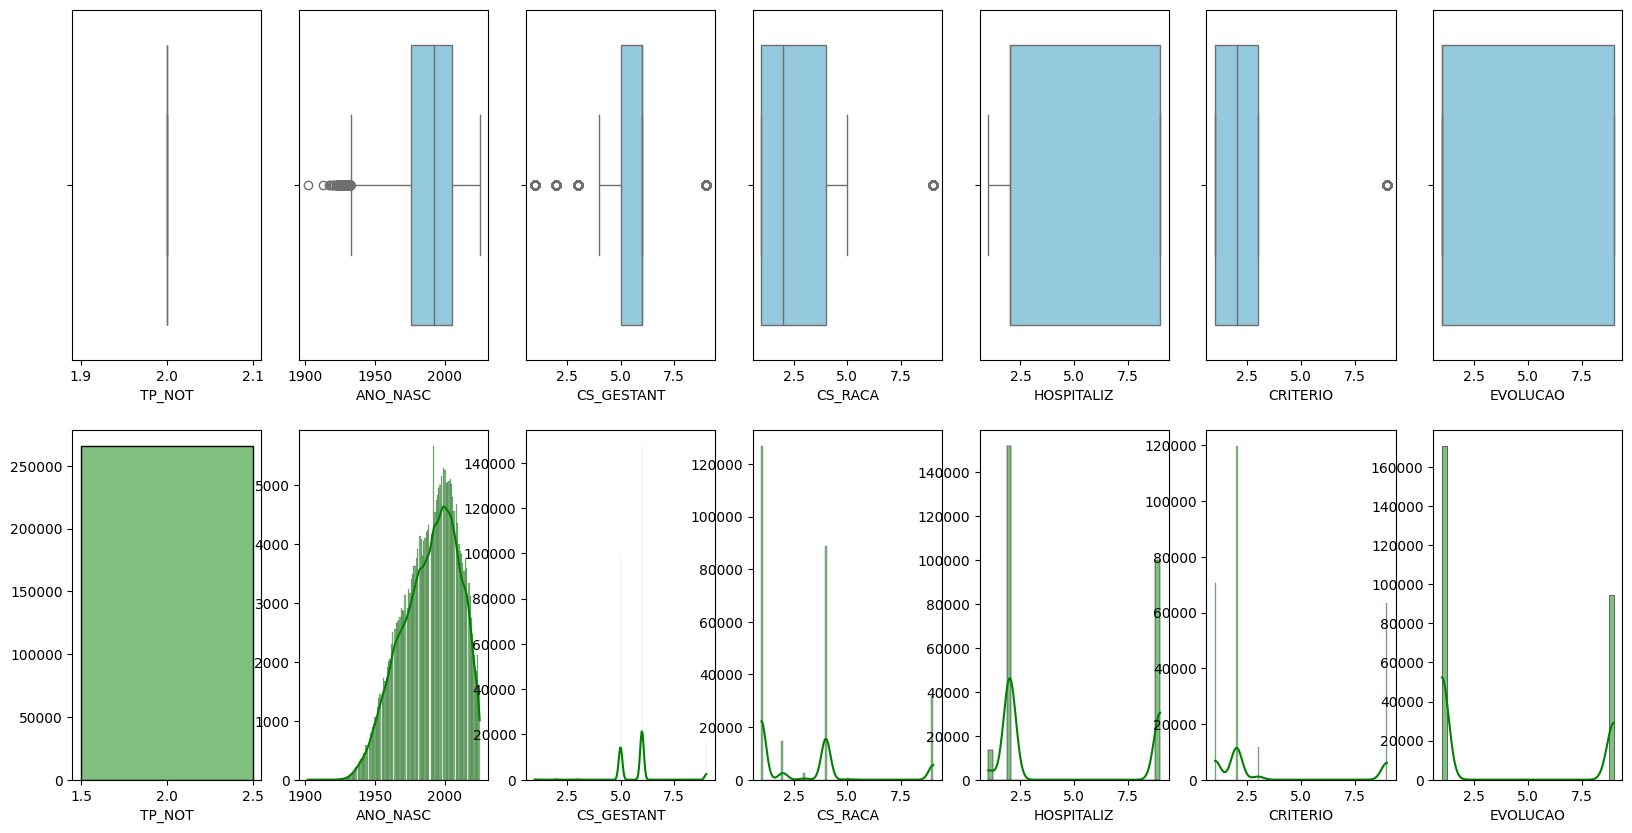

In [193]:
import matplotlib.pyplot as plt
import seaborn as sb

# MONTAR BOXPLOTS PARA VERIFICAR A DISTRIBUIÇÃO E OUTLIERS
numeric_cols = ['TP_NOT', 'ANO_NASC', 'CS_GESTANT', 'CS_RACA', 'HOSPITALIZ', 'CRITERIO', 'EVOLUCAO']

# Configurar uma grade de 2 e 7 colunas
fig, ax = plt.subplots(2, 7, figsize=(20, 10))

# Plotar os 14 gráficos
for i, col in enumerate(numeric_cols):
    # Linha 1 boxplots
    sb.boxplot(x=dados[col], ax=ax[0,i], color='skyblue')
    # Linha 2 histogramas
    sb.histplot(x=dados[col], ax=ax[1,i], color='green', kde=True)
    ax[1, i].set_ylabel('')